# RakForest CNN — Inference Demo

รับไฟล์เสียง `.wav` หรือ `.mp3` จำนวน 1 ไฟล์ แล้วแปลงเป็น mono, 16 kHz, แบ่งเป็นช่วงละ 5 วินาที จากนั้นใช้โมเดลที่เทรนไว้ทำนายทุกช่วงและเฉลี่ย probability

> Notebook นี้โหลด checkpoint อย่างเดียว ไม่มีการเทรนโมเดลใหม่ และไม่แก้ไข dataset หรือ checkpoint

Preprocessing ต้องตรงกับ `03_train_cnn.ipynb`: Mel-Spectrogram `n_fft=1024`, `hop_length=256`, `n_mels=64`, `f_min=20`, `f_max=8000`, log power และ per-sample normalization

In [1]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
from IPython.display import display

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "models" / "rakforest_cnn_best.pt").is_file():
            return candidate.resolve()
    raise FileNotFoundError("ไม่พบ models/rakforest_cnn_best.pt")

PROJECT_ROOT = find_project_root()
MODEL_PATH = PROJECT_ROOT / "models" / "rakforest_cnn_best.pt"
SAMPLE_RATE = 16_000
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS
CONFIDENCE_THRESHOLD = 0.70

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_PATH}")

Device: mps
Model: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/models/rakforest_cnn_best.pt


## 1. ระบุ path ไฟล์เสียง

In [2]:
# แก้ค่าเฉพาะบรรทัดนี้เป็น path ไฟล์เสียง .wav หรือ .mp3 เช่น "samples/example.mp3"
AUDIO_PATH = "/Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/forest_sound_dataset/logging/11_11130.wav"
if not AUDIO_PATH.strip():
    raise ValueError("กรุณาแก้ค่า AUDIO_PATH ในเซลล์นี้ก่อนรัน Notebook")

audio_path = Path(AUDIO_PATH).expanduser()
if not audio_path.is_absolute():
    audio_path = PROJECT_ROOT / audio_path
audio_path = audio_path.resolve()

if not audio_path.is_file():
    raise FileNotFoundError(f"ไม่พบไฟล์เสียง: {audio_path}")
if audio_path.suffix.lower() not in {".wav", ".mp3"}:
    raise ValueError("รองรับเฉพาะไฟล์ .wav และ .mp3")
print(f"ไฟล์ที่ใช้ทำนาย: {audio_path}")

ไฟล์ที่ใช้ทำนาย: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/forest_sound_dataset/logging/11_11130.wav


## 2. โหลดโมเดลและ preprocessing ให้เหมือนตอนเทรน

### ข้อจำกัดของคลาสที่โมเดลรู้จัก

โมเดลรู้จักเฉพาะ `fire`, `logging`, `natural sound` และ `poaching` เท่านั้น ดังนั้นไฟล์เสียงใหม่ที่แตกต่างจากชุดฝึกอาจถูกจัดเข้าใกล้หนึ่งในคลาสเหล่านี้ด้วย confidence ต่ำ ควรใช้ผลเป็นสัญญาณเบื้องต้นและตรวจสอบเพิ่มเติม

In [3]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
class_names = list(checkpoint["class_names"])

class SmallAudioCNN(nn.Module):
    # Architecture must match 03_train_cnn.ipynb exactly.
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.30), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallAudioCNN(len(class_names)).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=256,
    n_mels=64,
    f_min=20,
    f_max=SAMPLE_RATE // 2,
).to(DEVICE)

def to_log_mel(waveforms):
    mel = mel_transform(waveforms.to(DEVICE))
    mel = torch.log(mel.clamp_min(1e-6))
    mel = (mel - mel.mean(dim=(-2, -1), keepdim=True)) / (mel.std(dim=(-2, -1), keepdim=True) + 1e-6)
    return mel.unsqueeze(1)

print(f"Classes: {class_names}")
print("โหลด checkpoint สำเร็จ — ไม่มีการเทรนโมเดลใหม่")

Classes: ['fire', 'logging', 'natural sound', 'poaching']
โหลด checkpoint สำเร็จ — ไม่มีการเทรนโมเดลใหม่


## 3. แปลงเสียงและแบ่งเป็นช่วงละ 5 วินาที

In [4]:
# librosa handles WAV/MP3 decoding, mono conversion and resampling to 16 kHz.
waveform, actual_sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
waveform = waveform.astype(np.float32)

chunks = []
for start in range(0, max(len(waveform), 1), NUM_SAMPLES):
    chunk = waveform[start:start + NUM_SAMPLES]
    if len(chunk) < NUM_SAMPLES:
        chunk = np.pad(chunk, (0, NUM_SAMPLES - len(chunk)))
    chunks.append(chunk)

chunks = torch.from_numpy(np.stack(chunks)).float()
duration = len(waveform) / SAMPLE_RATE
print(f"Original duration: {duration:.2f} seconds")
print(f"จำนวนช่วงเสียงที่วิเคราะห์: {len(chunks)}")
print(f"Chunk shape: {tuple(chunks.shape)} | sample rate: {SAMPLE_RATE} Hz | mono: True")

Original duration: 5.00 seconds
จำนวนช่วงเสียงที่วิเคราะห์: 1
Chunk shape: (1, 80000) | sample rate: 16000 Hz | mono: True


## 4. ทำนายทุกช่วงและเฉลี่ย probability

In [5]:
with torch.no_grad():
    logits = model(to_log_mel(chunks))
    chunk_probabilities = torch.softmax(logits, dim=1)
    mean_probabilities = chunk_probabilities.mean(dim=0)

predicted_index = int(mean_probabilities.argmax().item())
predicted_class = class_names[predicted_index]
confidence = float(mean_probabilities[predicted_index].item())
probability_df = pd.DataFrame({
    "class": class_names,
    "probability": mean_probabilities.cpu().numpy(),
})
probability_df["probability_percent"] = probability_df["probability"] * 100

if confidence >= 0.70:
    result_status = "high"
    confidence_level = "สูง"
    result_message = f"ตรวจพบเสียงต้องสงสัย: {predicted_class}"
elif confidence >= 0.50:
    result_status = "medium"
    confidence_level = "ปานกลาง"
    result_message = f"อาจเป็นเสียง {predicted_class} — ควรตรวจสอบเพิ่มเติม"
else:
    result_status = "low"
    confidence_level = "ต่ำ"
    result_message = "ผลยังไม่แน่ชัด อาจเป็นเสียงนอกเหนือจากคลาสที่โมเดลรู้จัก"

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")
print(f"ระดับความเชื่อมั่น: {confidence_level}")
print(f"Status: {result_status}")
print(result_message)
print(f"จำนวนช่วงเสียงที่วิเคราะห์: {len(chunks)}")
display(probability_df.style.format({"probability": "{:.4f}", "probability_percent": "{:.2f}%"}))

Predicted class: logging
Confidence: 59.74%
ระดับความเชื่อมั่น: ปานกลาง
Status: medium
อาจเป็นเสียง logging — ควรตรวจสอบเพิ่มเติม
จำนวนช่วงเสียงที่วิเคราะห์: 1


,class,probability,probability_percent
0,fire,0.0052,0.52%
1,logging,0.5974,59.74%
2,natural sound,0.3942,39.42%
3,poaching,0.0032,0.32%


## 5. ภาพรวม probability

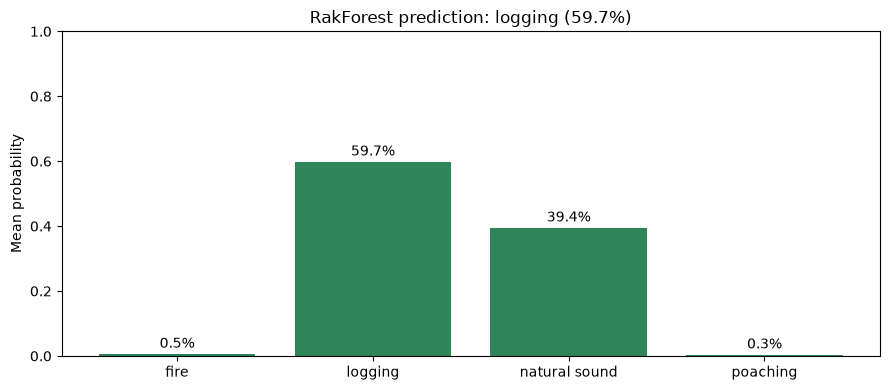

In [6]:
plt.figure(figsize=(9, 4))
bars = plt.bar(probability_df["class"], probability_df["probability"], color="#2f855a")
plt.ylim(0, 1)
plt.ylabel("Mean probability")
plt.title(f"RakForest prediction: {predicted_class} ({confidence:.1%})")
for bar, value in zip(bars, probability_df["probability"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.1%}", ha="center")
plt.tight_layout()
plt.show()

### หมายเหตุ

ถ้า confidence ต่ำกว่า 70% ให้ใช้ผลนี้เป็นสัญญาณเบื้องต้นเท่านั้น และตรวจสอบไฟล์เสียงเพิ่มเติมก่อนตัดสินใจ